# 🎯 Actionability Inference

Chạy model Actionability trên toàn bộ ESG sentences và tạo summary theo bank-year.

In [2]:
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
INPUT_PATH = Path("sentences_with_predictions.parquet")
MODEL_NAME = "huypham71/esg-action"
BATCH_SIZE = 16
MAX_LENGTH = 256
OUTPUT_PATH = Path("esg_sentences_with_actionability.parquet")
SUMMARY_PATH = Path("actionability_summary.csv")


BATCH_SIZE = 64
MAX_LENGTH = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1️⃣ Load Model

In [3]:
# Load model and tokenizer
print("Loading model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.to(device)
model.eval()

print(f"Model loaded! Labels: {model.config.id2label}")

Loading model...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/898 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.48G [00:00<?, ?B/s]

Model loaded! Labels: {0: 'Implemented', 1: 'Planning', 2: 'Indeterminate'}


## 2️⃣ Load Data

In [4]:
df_all = pd.read_parquet(INPUT_PATH)
print(f"Total sentences: {len(df_all):,}")
print(f"ESG sentences: {df_all['is_esg'].sum():,}")

# Filter only ESG sentences
df = df_all[df_all["is_esg"] == True].copy().reset_index(drop=True)
print(f"\nProcessing {len(df):,} ESG sentences")
print(f"\nBy topic:")
print(df["predicted_label"].value_counts())

Total sentences: 120,585
ESG sentences: 40,372

Processing 40,372 ESG sentences

By topic:
predicted_label
G              17888
S_product       8446
S_labor         7578
E               3545
S_community     2915
Name: count, dtype: int64


## 3️⃣ Batch Inference

In [5]:
def predict_batch(texts: list[str]) -> list[dict]:
    """Predict actionability for a batch of texts"""
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)
        preds = torch.argmax(probs, dim=-1)
        max_probs = probs.max(dim=-1).values

    results = []
    for pred, prob in zip(preds, max_probs):
        label = model.config.id2label[pred.item()]
        results.append({
            "action_label": label,
            "action_prob": prob.item(),
        })

    return results

In [6]:
print(f"Running inference with batch size {BATCH_SIZE}...")
sentences = df["sentence"].tolist()

all_results = []
for i in tqdm(range(0, len(sentences), BATCH_SIZE)):
    batch = sentences[i:i + BATCH_SIZE]
    results = predict_batch(batch)
    all_results.extend(results)

# Add predictions to dataframe
df["action_label"] = [r["action_label"] for r in all_results]
df["action_prob"] = [r["action_prob"] for r in all_results]

print(f"\n✅ Done! Predictions added.")

Running inference with batch size 64...


  0%|          | 0/631 [00:00<?, ?it/s]


✅ Done! Predictions added.


## 4️⃣ Results Overview

In [8]:
LABELS = ["Implemented", "Planning", "Indeterminate"]

In [9]:
print("=" * 50)
print("ACTIONABILITY DISTRIBUTION")
print("=" * 50)

action_counts = df["action_label"].value_counts()
action_pct = df["action_label"].value_counts(normalize=True) * 100

for label in LABELS:
    count = action_counts.get(label, 0)
    pct = action_pct.get(label, 0)
    print(f"{label:15} {count:>8,}  ({pct:5.1f}%)")

ACTIONABILITY DISTRIBUTION
Implemented       10,379  ( 25.7%)
Planning           1,060  (  2.6%)
Indeterminate     28,933  ( 71.7%)


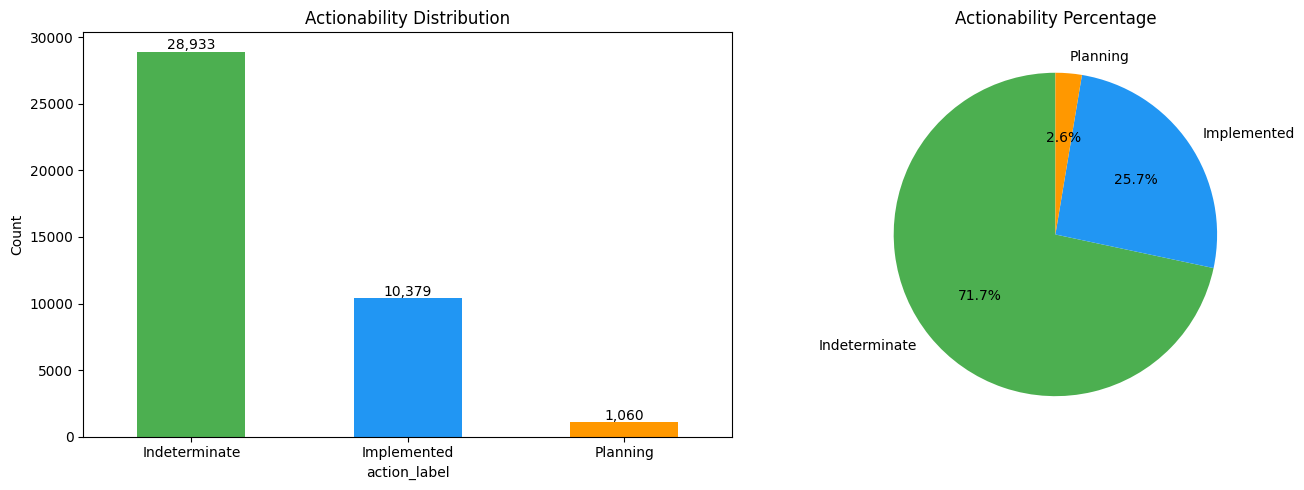

In [10]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ["#4CAF50", "#2196F3", "#FF9800"]
action_counts.plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("Actionability Distribution")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(action_counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha="center")

# Pie chart
axes[1].pie(action_counts.values, labels=action_counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90)
axes[1].set_title("Actionability Percentage")

plt.tight_layout()
plt.show()

## 5️⃣ Summary by Bank-Year

In [11]:
# Create summary table
summary = df.groupby(["bank", "year"]).apply(
    lambda x: pd.Series({
        "total_esg": len(x),
        "implemented": (x["action_label"] == "Implemented").sum(),
        "planning": (x["action_label"] == "Planning").sum(),
        "indeterminate": (x["action_label"] == "Indeterminate").sum(),
        "implemented_pct": (x["action_label"] == "Implemented").mean() * 100,
        "planning_pct": (x["action_label"] == "Planning").mean() * 100,
        "indeterminate_pct": (x["action_label"] == "Indeterminate").mean() * 100,
    })
).reset_index()

# Round percentages
summary["implemented_pct"] = summary["implemented_pct"].round(1)
summary["planning_pct"] = summary["planning_pct"].round(1)
summary["indeterminate_pct"] = summary["indeterminate_pct"].round(1)

print("=" * 80)
print("ACTIONABILITY BY BANK-YEAR")
print("=" * 80)
print(summary.to_string(index=False))

ACTIONABILITY BY BANK-YEAR
       bank  year  total_esg  implemented  planning  indeterminate  implemented_pct  planning_pct  indeterminate_pct
   agribank  2020      250.0        103.0       6.0          141.0             41.2           2.4               56.4
   agribank  2021      222.0         80.0       2.0          140.0             36.0           0.9               63.1
   agribank  2022      397.0        141.0       5.0          251.0             35.5           1.3               63.2
   agribank  2023      507.0        196.0       3.0          308.0             38.7           0.6               60.7
   agribank  2024      607.0        205.0      12.0          390.0             33.8           2.0               64.3
       bidv  2020      807.0        286.0      15.0          506.0             35.4           1.9               62.7
       bidv  2021     1005.0        364.0      17.0          624.0             36.2           1.7               62.1
       bidv  2022     1218.0        3

/tmp/ipython-input-4159504474.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(["bank", "year"]).apply(


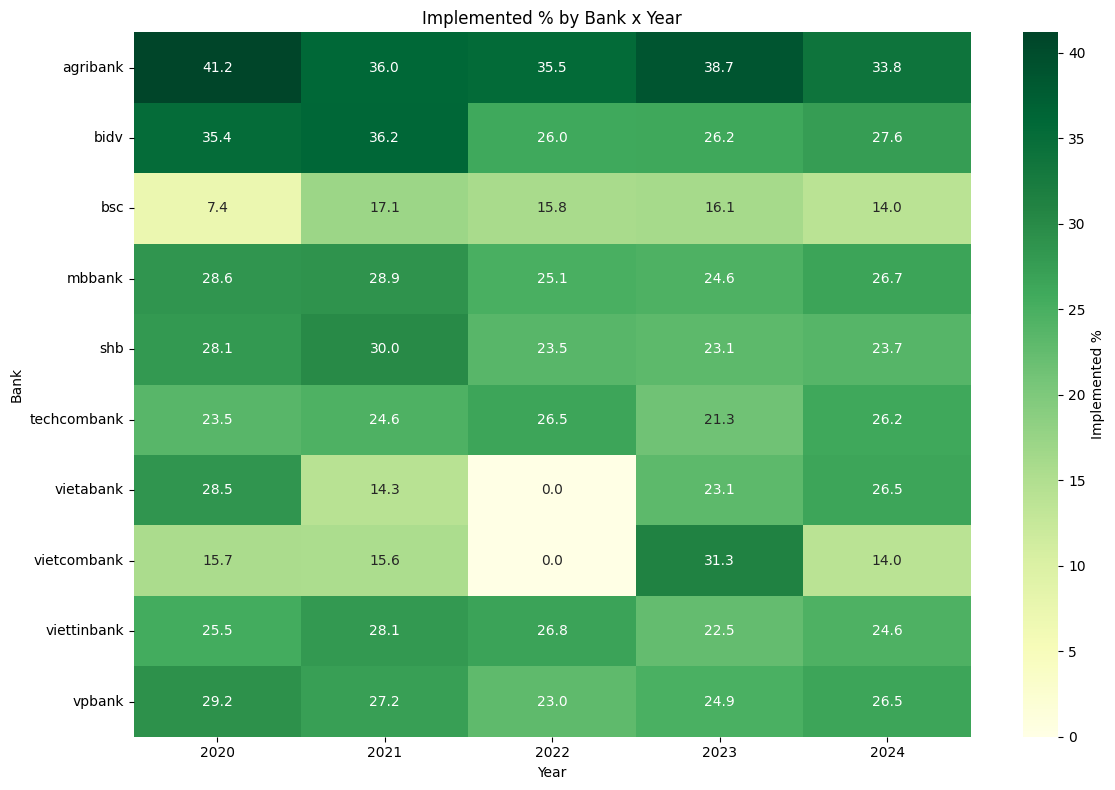

In [12]:
# Pivot table: Implemented % by bank x year
pivot = summary.pivot(index="bank", columns="year", values="implemented_pct").fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGn", cbar_kws={"label": "Implemented %"})
plt.title("Implemented % by Bank x Year")
plt.xlabel("Year")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()

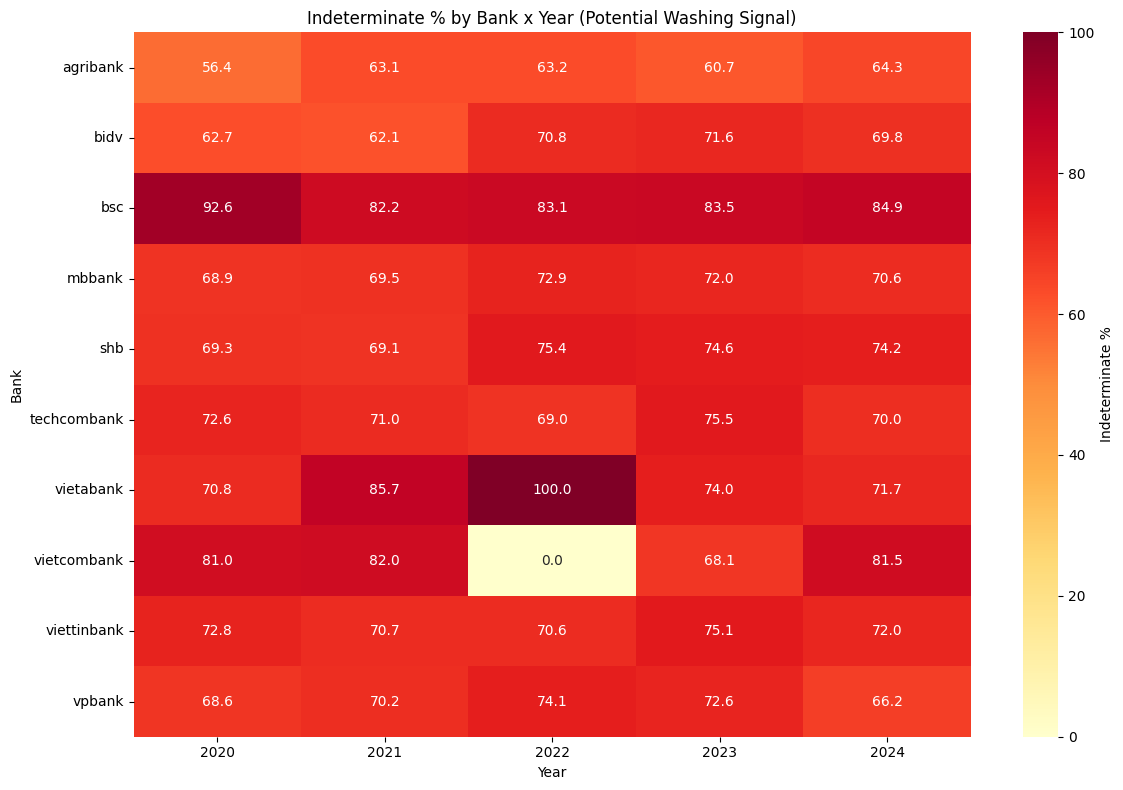

In [13]:
# Pivot table: Indeterminate % (proxy for potential washing)
pivot_indet = summary.pivot(index="bank", columns="year", values="indeterminate_pct").fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_indet, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Indeterminate %"})
plt.title("Indeterminate % by Bank x Year (Potential Washing Signal)")
plt.xlabel("Year")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()

## 6️⃣ Actionability by ESG Topic

Action Distribution by ESG Topic (%)
action_label     Implemented  Indeterminate  Planning
predicted_label                                      
E                       31.3           64.0       4.7
G                       21.3           76.6       2.1
S_community             31.2           67.3       1.4
S_labor                 23.2           75.0       1.8
S_product               33.0           63.1       3.9


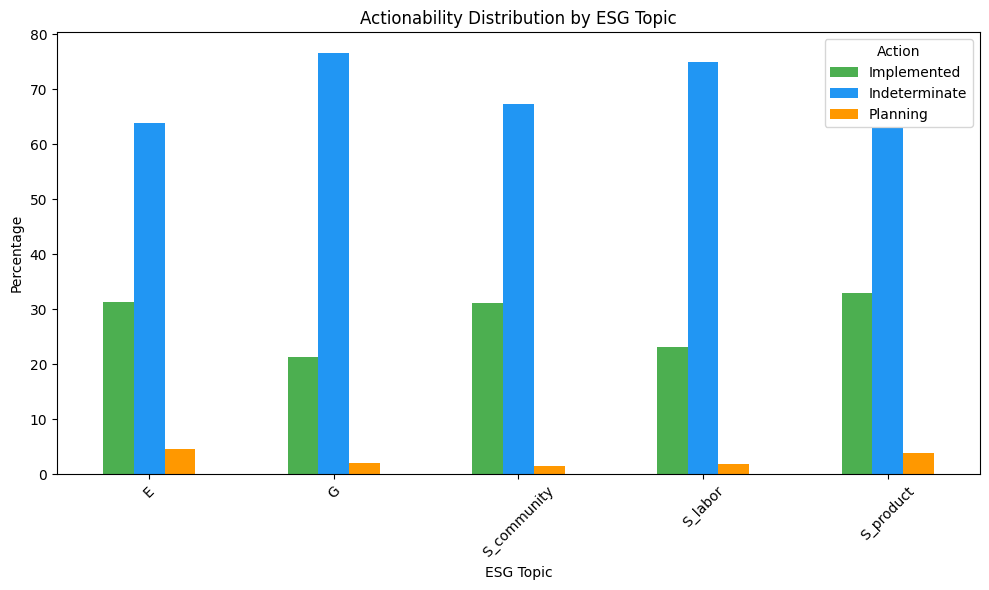

In [14]:
# Cross-tab: Action x ESG Topic
topic_action = pd.crosstab(df["predicted_label"], df["action_label"], normalize="index") * 100

print("Action Distribution by ESG Topic (%)")
print(topic_action.round(1))

# Visualization
topic_action.plot(kind="bar", figsize=(10, 6), color=colors)
plt.title("Actionability Distribution by ESG Topic")
plt.xlabel("ESG Topic")
plt.ylabel("Percentage")
plt.legend(title="Action")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7️⃣ Save Results

In [15]:
# Save full predictions
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(OUTPUT_PATH, index=False)
print(f"✅ Saved predictions: {OUTPUT_PATH}")

# Save summary
SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(SUMMARY_PATH, index=False)
print(f"✅ Saved summary: {SUMMARY_PATH}")

✅ Saved predictions: esg_sentences_with_actionability.parquet
✅ Saved summary: actionability_summary.csv


## 8️⃣ Sample Predictions

In [16]:
# Show sample predictions for each class

for label in LABELS:
    print(f"\n{'='*60}")
    print(f"{label.upper()} EXAMPLES")
    print("="*60)

    samples = df[df["action_label"] == label].sample(n=min(3, len(df[df["action_label"] == label])), random_state=42)
    for _, row in samples.iterrows():
        print(f"\n📝 {row['sentence'][:200]}..." if len(row['sentence']) > 200 else f"\n📝 {row['sentence']}")
        print(f"   Topic: {row['predicted_label']} | Bank: {row['bank']} | Year: {row['year']}")
        print(f"   Confidence: {row['action_prob']:.2%}")


IMPLEMENTED EXAMPLES

📝 | v | VietinBank tuân thủ quy định hiện hành (tối 
 thiểu 20 ngày theo khoản 4b, điều 11, Thông 
 tư 96/2020/TT-BTC; khoản 2.2, điều 9 Quy 
 chế thực hiện quyền số 09 năm 2023 của 
 Tổng công ty lưu k...
   Topic: G | Bank: viettinbank | Year: 2023
   Confidence: 94.55%

📝 BIDV cũng được Bộ Thông tin và truyền thông, NHNN xếp hạng nhất lần thứ 12 liên tiếp trong khối NHTM tại Việt Nam về chỉ số sẵn sàng cho phát triển và ứng dụng CNTT và có 06 sản phẩm ứng dụng CNTT đạt...
   Topic: S_product | Bank: bidv | Year: 2021
   Confidence: 96.18%

📝 + Tổng số ngày đào tạo trực tuyến tăng 2,46 lần.
   Topic: S_labor | Bank: agribank | Year: 2024
   Confidence: 55.21%

PLANNING EXAMPLES

📝 VPBank sẽ đẩy mạnh công tác chủ động phát hiện, cảnh báo sớm rủi ro, đặc biệt là rủi ro gian lận thông qua phân tích dữ liệu và áp dụng các giải pháp công nghệ.
   Topic: G | Bank: vpbank | Year: 2024
   Confidence: 99.57%

📝 Áp dụng chính sách kế toán riêng về ghi nhận dự phòng cho c

## 📊 Final Summary

In [17]:
print("="*60)
print("INFERENCE COMPLETE")
print("="*60)
print(f"Total ESG sentences: {len(df):,}")
print(f"\nActionability Distribution:")
for label in LABELS:
    count = (df["action_label"] == label).sum()
    pct = count / len(df) * 100
    print(f"  {label:15} {count:>8,}  ({pct:5.1f}%)")

print(f"\nOutputs saved:")
print(f"  - {OUTPUT_PATH}")
print(f"  - {SUMMARY_PATH}")

INFERENCE COMPLETE
Total ESG sentences: 40,372

Actionability Distribution:
  Implemented       10,379  ( 25.7%)
  Planning           1,060  (  2.6%)
  Indeterminate     28,933  ( 71.7%)

Outputs saved:
  - esg_sentences_with_actionability.parquet
  - actionability_summary.csv
